In [89]:
import os.path as op
import pickle
import pandas as pd
import numpy as np
import pyreadstat
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from matplotlib.colors import ListedColormap
import scipy

from scipy.stats import spearmanr, linregress
from scipy.ndimage import gaussian_filter1d

import mne
from scipy import stats
import statsmodels.api as sm

In [90]:
np.random.seed(42)

In [91]:
pipeline='NEARICA_behav_v3'
epoch_types=['task']
excluded_subjects=np.array(['C34','C36'])
left_handers=np.array(['C13','C20','C23','C40','C43','C46'])
min_trials_per_cond=5

time_bin_size = .2
time_bins = np.arange(-8, 15 + time_bin_size, time_bin_size)

n_pc_bins=3
smooth_kern=2

conditions=['kaleidoscope', 'obs fine', 'obs gross', 'exe fine', 'exe gross']
condition_events={
    'kaleidoscope': 'E  9',
    'obs fine': 'E 17', 
    'obs gross':'E 18',
    'exe fine': 'E 33', 
    'exe gross': 'E 34'
}



In [92]:
plt.rcParams.update({
    'font.size': 14,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

def add_subplot_label(ax, label, x=-.21, y=1.225):
    ax.text(x, y, label,  # Adjust left of y-axis
            transform=ax.transAxes,
            fontsize=26, va='top', ha='right')

typ_color=np.array([27,158,119])/255.0
dcd_color=np.array([117,112,179])/255.0
group_colors={
    'typ': typ_color,
    'dcd': dcd_color
}

In [93]:
exclude_typ=[]

all_bursts={
    'subject': [],
    'group': [],
    'epoch_type': [],
    'condition': [],
    'hemi': [],
    'cluster': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0,130)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

subjects = pd.read_csv('/home/bonaiuto/dcd_bursts/data/participants.tsv', sep='\t')
df, meta = pyreadstat.read_sav('/home/bonaiuto/dcd_bursts/CoMB_Dataset.sav')

subject_ids = subjects['participant_id']
for subj_id in subject_ids:
    group=df['Group'][np.where(df['SubjectID']==subj_id)[0]].values[0]
    mab_per=df['MABC_Percentile'][np.where(df['SubjectID']==subj_id)[0]].values[0]        
    if group==0 and mab_per<25:
        exclude_typ.append(subj_id)
        
    if not len(np.where(excluded_subjects==subj_id)[0]):
        subject_data_dir=op.join('/home/bonaiuto/dcd_bursts/data/derivatives', pipeline, subj_id, 'processed_data')
        for epoch_type in epoch_types:
            for cluster in ['C3','C4']:
                if cluster=='C3':
                    if np.isin(subj_id,left_handers):
                        hemi='ipsi'
                    else:
                        hemi='contra'
                else:
                    if np.isin(subj_id,left_handers):
                        hemi='contra'
                    else:
                        hemi='ipsi'
                fname=op.join(subject_data_dir, f'bursts_{subj_id}_{epoch_type}_{cluster}.pickle')
                if op.exists(fname):
                    with open(fname,'rb') as file:
                        bursts=pickle.load(file)
                    n_bursts=len(bursts['trial'])
                    bursts['group']=np.array([group for i in range(n_bursts)])
                    bursts['hemi']=np.array([hemi for i in range(n_bursts)])
                    bursts['cluster']=np.array([cluster for i in range(n_bursts)])
                    for key in bursts.keys():
                        if key=='waveform_times':
                            all_bursts[key] = bursts[key]
                        elif key=='waveform':
                            all_bursts[key] = np.vstack([all_bursts[key], bursts[key]])
                        else:
                            all_bursts[key] = np.hstack([all_bursts[key], bursts[key]])
    else:
        print(f'skipping {subj_id}')

skipping C34
skipping C36


In [106]:
all_pow={
    hemi: {
        group: {
            condition: [] for condition in conditions
        } for group in ['typ','dcd']
    } for hemi in ['ipsi','contra']
}
WINDOWS = {
    "baseline": (-7.0, -1.0),
    "task": (1.0, 9.0),
    "post-task": (11.0, 14.0),
}

rows = []

subjects = pd.read_csv('/home/bonaiuto/dcd_bursts/data/participants.tsv', sep='\t')
df, meta = pyreadstat.read_sav('/home/bonaiuto/dcd_bursts/CoMB_Dataset.sav')

subject_ids = subjects['participant_id']
for subj_id in subject_ids:
    group=df['Group'][np.where(df['SubjectID']==subj_id)[0]].values[0]
    mab_per=df['MABC_Percentile'][np.where(df['SubjectID']==subj_id)[0]].values[0]        
    if group==0 and mab_per<25:
        continue
    if group==0:
        group='typ'
    else:
        group='dcd'
        
    if not len(np.where(excluded_subjects==subj_id)[0]):
        subject_data_dir=op.join('/home/bonaiuto/dcd_bursts/data/derivatives', pipeline, subj_id, 'processed_data')
        for epoch_type in epoch_types:
            for cluster in ['C3','C4']:
                if cluster=='C3':
                    if np.isin(subj_id,left_handers):
                        hemi='ipsi'
                    else:
                        hemi='contra'
                else:
                    if np.isin(subj_id,left_handers):
                        hemi='contra'
                    else:
                        hemi='ipsi'
                fname=op.join(subject_data_dir, f'beta_pow_{subj_id}_{epoch_type}_{cluster}.pickle')
                if op.exists(fname):
                    with open(fname,'rb') as file:
                        cond_beta_pow=pickle.load(file)
                        for cond in cond_beta_pow:
                            if cond == 'E  9':
                                condition='kaleidoscope'
                            elif cond == 'E 17': 
                                condition='obs fine'
                            elif cond == 'E 18':
                                condition='obs gross'
                            elif cond == 'E 33':
                                condition='exe fine'
                            elif cond == 'E 34':
                                condition='exe gross'
                            else:
                                continue
                            if cond_beta_pow[cond][0].shape[0]>=min_trials_per_cond:
                                all_trials_pow=np.squeeze(np.array(cond_beta_pow[cond]))
                                m_pow=np.mean(all_trials_pow,axis=0)
                                pow_times=np.linspace(-8,15,all_trials_pow.shape[1])
                                for tr_idx in range(all_trials_pow.shape[0]):
                                    trial_pow=all_trials_pow[tr_idx,:]
                                    for win_name, (t0, t1) in WINDOWS.items():
                                        w_idx = (pow_times >= t0) & (pow_times <= t1)
                                        if not np.any(w_idx):
                                            continue
                                        win_pow = float(np.mean(trial_pow[w_idx]))

                                        rows.append(
                                            {
                                                "subject": subj_id,
                                                "group": group,
                                                "hemi": hemi,
                                                "condition": condition,
                                                "window": win_name,
                                                "power": win_pow,
                                            }
                                        )
                                all_pow[hemi][group][condition].append(m_pow)                    
    else:
        print(f'skipping {subj_id}')
# Write to CSV
out_df = pd.DataFrame(rows, columns=["subject", "group", "hemi", "condition", "window", "power"])
out_path = "./trial_beta_power_windows.csv"
out_df.to_csv(out_path, index=False)

skipping C34
skipping C36


stat_fun(H1): min=0.000000 max=5.533133
Running initial clustering …
Found 25 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 2.093024
stat_fun(H1): min=-1.986624 max=3.453598
Running initial clustering …
Found 14 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

Using a threshold of 2.100922
stat_fun(H1): min=-3.495301 max=3.173008
Running initial clustering …
Found 7 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

Using a threshold of 2.093024
stat_fun(H1): min=-4.642695 max=1.985411
Running initial clustering …
Found 14 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

Using a threshold of 2.100922
stat_fun(H1): min=-4.320243 max=2.711381
Running initial clustering …
Found 21 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

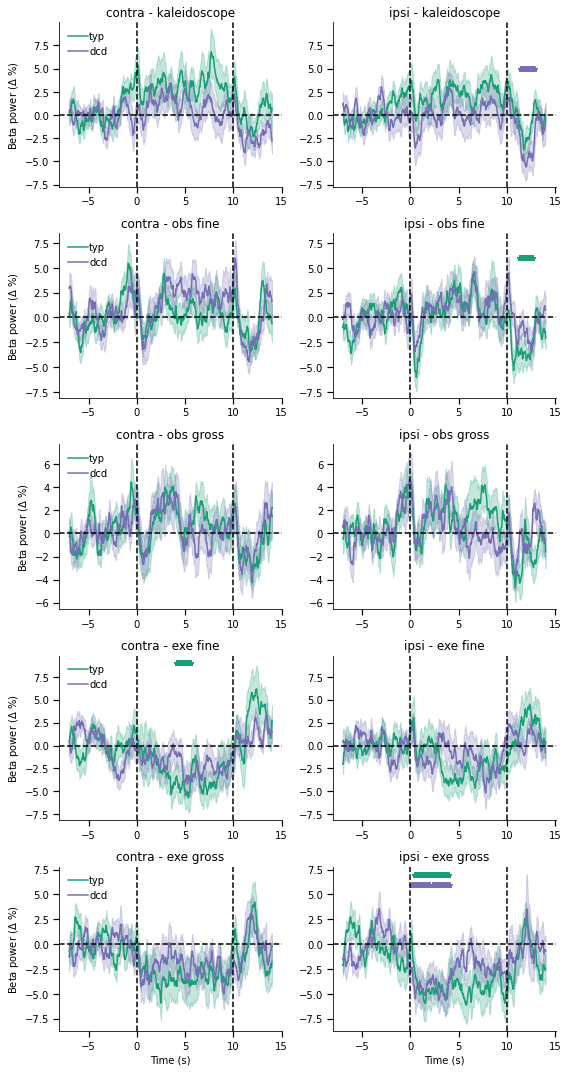

In [7]:
fig=plt.figure(figsize=(8,3*len(conditions)))
gs = GridSpec(len(conditions), 2, figure=fig)
for cond_idx, condition in enumerate(conditions):
    hemi_axes=[]
    for hemi_idx, hemi in enumerate(['contra','ipsi']):
        ax = fig.add_subplot(gs[cond_idx, hemi_idx])
        
        bc_pow={
            group: [] for group in ['typ', 'dcd']
        }
        for group in ['typ','dcd']:
            for subj_pow in all_pow[hemi][group][condition]:
                pow_times=np.linspace(-8,15,subj_pow.shape[-1])
                b_idx=(pow_times>=-7) & (pow_times<=-1)
                b_pow=np.mean(subj_pow[b_idx])
                subj_pow=(subj_pow-b_pow)/b_pow*100
                bc_pow[group].append(subj_pow)
            t_idx=(pow_times>=-7) & (pow_times<=14)
            bc_pow[group]=np.array(bc_pow[group])[:,t_idx]
            
        data = [bc_pow['typ'], bc_pow['dcd']]        
        n1 = bc_pow['typ'].shape[0]
        n2 = bc_pow['dcd'].shape[0]
        dof = n1 + n2 - 2
        t_crit = stats.t.ppf(1 - 0.05/2, dof)
        
        T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            data,
            n_permutations=1000,
            threshold=t_crit,
            tail=0,
            out_type='mask',
            n_jobs=-1
        )
        for group in ['typ','dcd']:
            m_pow=np.mean(bc_pow[group],axis=0)
            se_pow=np.std(bc_pow[group],axis=0)/np.sqrt(bc_pow[group].shape[0])
            ax.plot(
                pow_times[t_idx],
                m_pow, 
                label=group, 
                color=group_colors[group]
            )
            ax.fill_between(
                pow_times[t_idx],
                m_pow-se_pow,
                m_pow+se_pow,
                color=group_colors[group],
                alpha=.25
            )
        yl = ax.get_ylim()
        py = yl[1] + .1 * (yl[1] - 0)
        for cluster_slice, cluster_pval in zip(clusters, cluster_p_values):
            if cluster_pval < 0.05:
                sl = cluster_slice[0]
                idx = np.arange(sl.start, sl.stop)
                ax.plot(pow_times[t_idx][idx], np.full_like(idx, py), '*', color='r')
        for g_idx, group in enumerate(['typ','dcd']):
            group_T_obs, group_clusters, group_cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
                bc_pow[group],
                n_permutations=10000,
                tail=0,
                n_jobs=-1
            )
            for cluster_slice, cluster_pval in zip(group_clusters, group_cluster_p_values):
                if cluster_pval < 0.05:
                    sl = cluster_slice[0]
                    ax.plot(pow_times[t_idx][sl], np.full_like(sl, py-(1+g_idx)), '*', color=group_colors[group])
        ax.axvline(0,color='k',linestyle='--')
        ax.axhline(0,color='k',linestyle='--')
        ax.axvline(10,color='k',linestyle='--')
        ax.set_title(f'{hemi} - {condition}')
        if cond_idx==(len(conditions)-1):
            ax.set_xlabel('Time (s)')
        if hemi_idx==0:
            ax.set_ylabel(r'Beta power ($\Delta$ %)')
    
        if hemi_idx==0:
            ax.legend()
        hemi_axes.append(ax)
    yl=[
        np.min([ax.get_ylim()[0] for ax in hemi_axes]),
        np.max([ax.get_ylim()[1] for ax in hemi_axes]),
    ]
    for ax in hemi_axes:
        ax.set_ylim(yl)
    plt.tight_layout()
    
plt.savefig('./manuscript/figX_beta_power.pdf',dpi=600)

In [8]:
print('Excluded because of low MABC percentile')
print(exclude_typ)

Excluded because of low MABC percentile
['C06', 'C07', 'C08', 'C31', 'C32', 'C35', 'C39', 'C55', 'C58']


In [9]:
include_typ_idx = ~np.isin(all_bursts['subject'], exclude_typ)
typ_idx=np.where(include_typ_idx & (all_bursts['group']==0))[0]
dcd_idx=np.where(all_bursts['group']==1)[0]

In [10]:
print(np.unique(all_bursts['subject'][typ_idx]))
print(np.unique(all_bursts['subject'][dcd_idx]))

['C03' 'C04' 'C05' 'C09' 'C14' 'C18' 'C21' 'C22' 'C23' 'C24' 'C29' 'C30'
 'C38' 'C41' 'C42' 'C45' 'C47' 'C48' 'C50' 'C51' 'C52' 'C53' 'C54' 'C57']
['C10' 'C11' 'C12' 'C13' 'C15' 'C16' 'C17' 'C19' 'C20' 'C25' 'C26' 'C27'
 'C28' 'C33' 'C37' 'C40' 'C43' 'C44' 'C46' 'C49' 'C56']


In [11]:
n_typ=len(np.unique(all_bursts['subject'][typ_idx]))
n_dcd=len(np.unique(all_bursts['subject'][dcd_idx]))
print(f'N typical={n_typ}')
print(f'N DCD={n_dcd}')

N typical=24
N DCD=21


In [12]:
burst_times=all_bursts['waveform_times']
typ_pca = PCA(n_components=20)
typ_burst_std=RobustScaler().fit_transform(all_bursts['waveform'][typ_idx,:])
typ_pca=typ_pca.fit(typ_burst_std)

dcd_pca = PCA(n_components=20)
dcd_burst_std=RobustScaler().fit_transform(all_bursts['waveform'][dcd_idx,:])
dcd_pca=dcd_pca.fit(dcd_burst_std)

def spearman_correlation_matrix(pca1, pca2):
    eigenvectors1 = pca1.components_.T
    eigenvectors2 = pca2.components_.T
    n_components = eigenvectors1.shape[1]
    
    corr_matrix = np.zeros((n_components, n_components))
    for i in range(n_components):
        for j in range(n_components):
            corr, _ = spearmanr(eigenvectors1[:, i], eigenvectors2[:, j])
            corr_matrix[i, j] = abs(corr)  # Absolute value of the Spearman correlation
    return corr_matrix

pca_corr_matrix = spearman_correlation_matrix(typ_pca, dcd_pca)
max_corrs=[]
for i in range(pca_corr_matrix.shape[0]):
    max_corrs.append(np.max(pca_corr_matrix[i,:]))
print(f'min={np.min(max_corrs)}, max={np.max(max_corrs)}')


min=0.8544019445847956, max=0.9997104972073905


In [113]:
max_corrs

[0.9997104972073905,
 0.9885072853650875,
 0.9860874790042196,
 0.988392576711412,
 0.994248180365702,
 0.9901186688333856,
 0.9499979516311845,
 0.9443171421158284,
 0.9873328872441246,
 0.9797621161015444,
 0.9728031244452335,
 0.9734749894167611,
 0.9708366903822254,
 0.8544019445847956,
 0.9539635936582501,
 0.8860287590981715,
 0.955471193106556,
 0.9530240751614797,
 0.940941430307665,
 0.9215993663712462]

In [13]:
typ_psd_data=scipy.io.loadmat(op.join('/home/bonaiuto/dcd_bursts/data/derivatives',pipeline,"processed_psd_typ.mat"))
dcd_psd_data=scipy.io.loadmat(op.join('/home/bonaiuto/dcd_bursts/data/derivatives',pipeline,"processed_psd_dcd.mat"))

In [14]:
psd_freqs=np.squeeze(typ_psd_data['frex'])
typ_psd=typ_psd_data['psd']
dcd_psd=dcd_psd_data['psd']
typ_periodic=typ_psd_data['periodic']
dcd_periodic=dcd_psd_data['periodic']
c_chan_idx=[7,23]

In [15]:
loaded_lhc_data = np.load(op.join('/home/bonaiuto/dcd_bursts/data/derivatives', pipeline, f'lhc.npz'), allow_pickle=True)
lhc = loaded_lhc_data['lhc'].item()
lags = loaded_lhc_data['lags']
lhc_freqs = loaded_lhc_data['freqs']

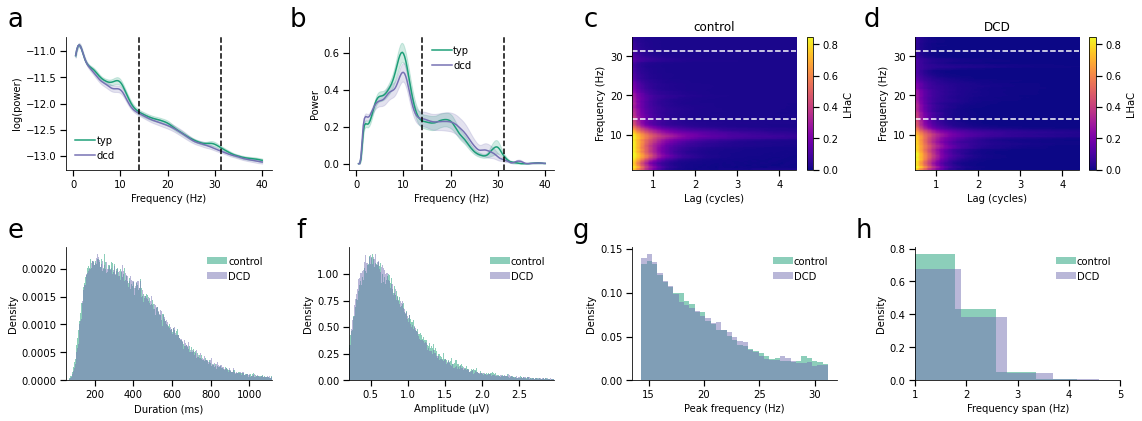

In [16]:
plt.figure(figsize=(16,6))
ax=plt.subplot(2,4,1)
typ_c_psds=np.mean(np.log10(typ_psd[:,c_chan_idx,:]),axis=1)
m_typ=np.mean(typ_c_psds,axis=0)
se_typ=np.std(typ_c_psds,axis=0)/np.sqrt(typ_c_psds.shape[0])

dcd_c_psds=np.mean(np.log10(dcd_psd[:,c_chan_idx,:]),axis=1)
m_dcd=np.mean(dcd_c_psds,axis=0)
se_dcd=np.std(dcd_c_psds,axis=0)/np.sqrt(dcd_c_psds.shape[0])
ax.plot(psd_freqs,m_typ,label='typ',color=typ_color)
ax.fill_between(psd_freqs, m_typ-se_typ, m_typ+se_typ, alpha=.2,color=typ_color)
ax.plot(psd_freqs,m_dcd,label='dcd',color=dcd_color)
ax.fill_between(psd_freqs, m_dcd-se_dcd, m_dcd+se_dcd, alpha=.2,color=dcd_color)
ax.axvline(14,color='k',linestyle='--')
ax.axvline(31.25,color='k',linestyle='--')
ax.legend()
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('log(power)')
add_subplot_label(ax, 'a')

ax=plt.subplot(2,4,2)
typ_c_psds=np.mean(typ_periodic[:,c_chan_idx,:],axis=1)
typ_c_psds[typ_c_psds<0]=0
m_typ=np.mean(typ_c_psds,axis=0)
se_typ=np.std(typ_c_psds,axis=0)/np.sqrt(typ_c_psds.shape[0])

dcd_c_psds=np.mean(dcd_periodic[:,c_chan_idx,:],axis=1)
dcd_c_psds[dcd_c_psds<0]=0
m_dcd=np.mean(dcd_c_psds,axis=0)
se_dcd=np.std(dcd_c_psds,axis=0)/np.sqrt(dcd_c_psds.shape[0])
ax.plot(psd_freqs,m_typ,label='typ',color=typ_color)
ax.fill_between(psd_freqs, m_typ-se_typ, m_typ+se_typ, alpha=.2,color=typ_color)
ax.plot(psd_freqs,m_dcd,label='dcd',color=dcd_color)
ax.fill_between(psd_freqs, m_dcd-se_dcd, m_dcd+se_dcd, alpha=.2,color=dcd_color)
ax.axvline(14,color='k',linestyle='--')
ax.axvline(31.25,color='k',linestyle='--')
ax.legend()
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power')
add_subplot_label(ax, 'b')

ax=plt.subplot(2,4,3)
l_idx=(lags>=0.5)
f_idx=(lhc_freqs<=35)
typ_contra=np.mean(lhc['typ']['contra'][:,f_idx][:,:,l_idx],axis=0)
typ_ipsi=np.mean(lhc['typ']['ipsi'][:,f_idx][:,:,l_idx],axis=0)
typ_lhc=np.mean(np.stack([typ_contra,typ_ipsi]),axis=0)
dcd_contra=np.mean(lhc['dcd']['contra'][:,f_idx][:,:,l_idx],axis=0)
dcd_ipsi=np.mean(lhc['dcd']['ipsi'][:,f_idx][:,:,l_idx],axis=0)
dcd_lhc=np.mean(np.stack([dcd_contra,dcd_ipsi]),axis=0)
max_lhc=np.max(np.vstack([
    typ_lhc[:],
    dcd_lhc[:]
]))
im=plt.imshow(
    typ_lhc,
    origin='lower',
    aspect='auto',
    extent=[lags[l_idx][0], lags[l_idx][-1], lhc_freqs[f_idx][0], lhc_freqs[f_idx][-1]],
    vmin=0,
    vmax=max_lhc,
    cmap='plasma'
)
plt.colorbar(im, label="LHaC")
ax.axhline(14,color='w',linestyle='--')
ax.axhline(31.25,color='w',linestyle='--')
ax.set_title('control')
ax.set_xlabel('Lag (cycles)')
ax.set_ylabel('Frequency (Hz)')
add_subplot_label(ax, 'c')

ax=plt.subplot(2,4,4)
im=plt.imshow(
    dcd_lhc,
    origin='lower',
    aspect='auto',
    extent=[lags[l_idx][0], lags[l_idx][-1], lhc_freqs[f_idx][0], lhc_freqs[f_idx][-1]],
    vmin=0,
    vmax=max_lhc,
    cmap='plasma'
)
plt.colorbar(im, label="LHaC")
ax.axhline(14,color='w',linestyle='--')
ax.axhline(31.25,color='w',linestyle='--')
ax.set_title('DCD')
ax.set_xlabel('Lag (cycles)')
ax.set_ylabel('Frequency (Hz)')
add_subplot_label(ax, 'd')

ax=plt.subplot(2,4,5)
_=plt.hist(
    all_bursts['fwhm_time'][typ_idx]*1000,
    855,
    alpha=.5,
    label='control',
    density=True,
    color=typ_color
)
_=plt.hist(
    all_bursts['fwhm_time'][dcd_idx]*1000,
    1110,
    alpha=.5,
    label='DCD',
    density=True,
    color=dcd_color
)
plt.legend()
plt.xlim(np.percentile(all_bursts['fwhm_time']*1000,[0,99]))
plt.ylabel('Density')
plt.xlabel('Duration (ms)')
add_subplot_label(ax, 'e')

ax=plt.subplot(2,4,6)
_=plt.hist(
    all_bursts['peak_amp_base'][typ_idx]*1e6,
    1000,
    alpha=.5,
    label='control',
    density=True, 
    color=typ_color
)
_=plt.hist(
    all_bursts['peak_amp_base'][dcd_idx]*1e6,
    1000,
    alpha=.5,
    label='DCD',
    density=True,
    color=dcd_color
)
plt.legend()
plt.xlim(np.percentile(all_bursts['peak_amp_base']*1e6,[1.5,99]))
plt.ylabel('Density')
plt.xlabel('Amplitude (µV)')
add_subplot_label(ax, 'f')

ax=plt.subplot(2,4,7)   
_=plt.hist(
    all_bursts['peak_freq'][typ_idx],
    35,
    alpha=.5,
    label='control',
    density=True, 
    color=typ_color
)
_=plt.hist(
    all_bursts['peak_freq'][dcd_idx],
    35,
    alpha=.5,
    label='DCD',
    density=True,
    color=dcd_color
)
plt.legend()
plt.ylabel('Density')
plt.xlabel('Peak frequency (Hz)')
add_subplot_label(ax, 'g')

ax=plt.subplot(2,4,8)
_=plt.hist(
    all_bursts['fwhm_freq'][typ_idx],
    15,
    alpha=.5,
    label='control',
    density=True, 
    color=typ_color
)
_=plt.hist(
    all_bursts['fwhm_freq'][dcd_idx],
    11,
    alpha=.5,
    label='DCD',
    density=True,
    color=dcd_color
)
plt.legend()
plt.xlim([1,5])
plt.ylabel('Density')
plt.xlabel('Frequency span (Hz)')
add_subplot_label(ax, 'h')

plt.tight_layout()

plt.savefig('./manuscript/figX_burst_feature_comparison.pdf',dpi=600)

In [28]:
def permutation_test(data1, data2, n_permutations=100000):
    # Observed difference in means
    obs_diff = np.nanmean(data1) - np.nanmean(data2)
    
    # Combine data and shuffle labels
    combined_data = np.concatenate([data1, data2])
    n1 = len(data1)
    
    # Permutation test
    perm_diffs = []
    for _ in range(n_permutations):
        np.random.shuffle(combined_data)
        perm_diff = np.nanmean(combined_data[:n1]) - np.nanmean(combined_data[n1:])
        perm_diffs.append(perm_diff)
    
    # Calculate p-value
    perm_diffs = np.array(perm_diffs)
    p_value = np.nanmean(np.abs(perm_diffs) >= np.abs(obs_diff))
    return obs_diff, p_value

def paired_permutation_test(data1, data2, n_permutations=1000, seed=1):
    rng = np.random.default_rng(seed)
    # Compute observed difference in means
    diffs = np.array(data1) - np.array(data2)
    obs_diff = np.nanmean(diffs)
    
    # Perform permutations by randomly flipping signs
    perm_diffs = []
    for _ in range(n_permutations):
        sign_flips = rng.choice([-1, 1], size=len(diffs), replace=True)
        perm_diff = np.nanmean(diffs * sign_flips)
        perm_diffs.append(perm_diff)
    
    # Calculate p-value
    perm_diffs = np.array(perm_diffs)
    p_value = np.nanmean(np.abs(perm_diffs) >= np.abs(obs_diff))
    
    return obs_diff, p_value

In [107]:
typ_subjects=np.unique(all_bursts['subject'][typ_idx])
dcd_subjects=np.unique(all_bursts['subject'][dcd_idx])
tf_features=['fwhm_time','peak_amp_base','peak_freq','fwhm_freq']
subj_burst_features={}
for feature in tf_features:
    subj_burst_features[feature]={'typ': [], 'dcd': []}

for subject in typ_subjects:
    for feature in tf_features:
        mean_val=np.mean(all_bursts[feature][all_bursts['subject']==subject])
        if feature=='peak_amp_base':
            mean_val=mean_val/1e-6
        subj_burst_features[feature]['typ'].append(mean_val)

for subject in dcd_subjects:
    for feature in tf_features:
        mean_val=np.mean(all_bursts[feature][all_bursts['subject']==subject])
        if feature=='peak_amp_base':
            mean_val=mean_val/1e-6
        subj_burst_features[feature]['dcd'].append(mean_val)
        
for feature in tf_features:
    typ_mean=np.mean(subj_burst_features[feature]['typ'])
    typ_sd=np.std(subj_burst_features[feature]['typ'])
    dcd_mean=np.mean(subj_burst_features[feature]['dcd'])
    dcd_sd=np.std(subj_burst_features[feature]['dcd'])
    obs_diff, p_value=permutation_test(subj_burst_features[feature]['typ'], subj_burst_features[feature]['dcd'])
    print(f'{feature} Mtyp={typ_mean}, SD={typ_sd}, Mdcd={dcd_mean}, SD={dcd_sd}, p={p_value}')

fwhm_time Mtyp=0.4202617996219189, SD=0.0487335534530353, Mdcd=0.4176762220413933, SD=0.05322164391219092, p=0.8689
peak_amp_base Mtyp=0.9432907063737028, SD=0.3209220053578122, Mdcd=0.9395234702487578, SD=0.49961674919096777, p=0.97799
peak_freq Mtyp=19.544241450666913, SD=1.1740893320410788, Mdcd=19.664203936993903, SD=1.3881833859427288, p=0.76259
fwhm_freq Mtyp=1.4552637451471113, SD=0.09019975651381167, Mdcd=1.4536690763359303, SD=0.12693743093583876, p=0.96378


stat_fun(H1): min=0.000009 max=11.726673
Running initial clustering …
Found 6 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000157 max=3.859091
Running initial clustering …
Found 2 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000166 max=9.768290
Running initial clustering …
Found 3 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000025 max=9.114195
Running initial clustering …
Found 5 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

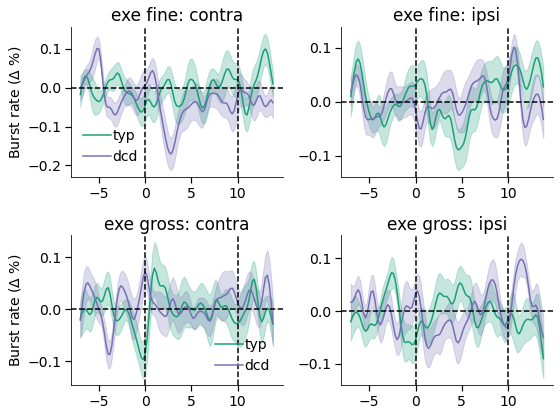

In [111]:
subjects = np.unique(all_bursts['subject'][np.where(include_typ_idx)[0]])
typ_subj = np.unique(all_bursts['subject'][np.where(include_typ_idx & (all_bursts['group'] == 0))[0]])
dcd_subj = np.unique(all_bursts['subject'][np.where(all_bursts['group'] == 1)[0]])

condition_rates = {
    hemi: {
        cond: {
            group: [] for group in ['typ','dcd']
        } for cond in ['exe fine','exe gross']
    } for hemi in ['contra','ipsi']
}

for subject in subjects:
    group_val = np.unique(all_bursts['group'][np.where(all_bursts['subject'] == subject)[0]])[0]
    group = 'typ' if group_val == 0 else 'dcd'
    for hemi in ['contra','ipsi']:
        subj_idx = (all_bursts['subject'] == subject) & (all_bursts['hemi'] == hemi)

        for cond in ['exe fine','exe gross']:
            event=condition_events[cond]
            cond_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['condition'] == event)])
            if len(cond_trials) >= min_trials_per_cond:
                unsmoothed_rate, _ = np.histogram(all_bursts['peak_time'][subj_idx & (all_bursts['condition'] == event)], bins=time_bins)
                unsmoothed_rate = (unsmoothed_rate * (1 / time_bin_size)) / len(cond_trials)                

                smoothed_rate = gaussian_filter1d(unsmoothed_rate, sigma=smooth_kern, axis=0, mode="nearest")
                smoothed_base_rate = np.mean(smoothed_rate[(time_bins[:-1]>=-7) & (time_bins[:-1]<=-1)])
                smoothed_bc_rate = (smoothed_rate - smoothed_base_rate)
                condition_rates[hemi][cond][group].append(smoothed_bc_rate)

plt_time_bins = time_bins[:-1]
t_idx=(plt_time_bins>=-7) & (plt_time_bins<=14)

for hemi in ['contra','ipsi']:
    for cond in ['exe fine','exe gross']:
        for group in ['typ','dcd']:
            condition_rates[hemi][cond][group]=np.vstack(condition_rates[hemi][cond][group])[:,t_idx]


fig=plt.figure(figsize=(8,3*len(['exe fine','exe gross'])))
gs = GridSpec(len(['exe fine','exe gross']), 2, figure=fig)

all_ps=[]

for cond_idx, cond in enumerate(['exe fine','exe gross']):        
    for hemi_idx, hemi in enumerate(['contra','ipsi']):
        ax = fig.add_subplot(gs[cond_idx, hemi_idx])
        data = [condition_rates[hemi][cond]['typ'], condition_rates[hemi][cond]['dcd']] 
        n1 = data[0].shape[0]
        n2 = data[1].shape[0]
        dof = n1 + n2 - 2
        t_crit = stats.t.ppf(1 - 0.05/2, dof)

        T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            data,
            n_permutations=1000,
            threshold=t_crit,
            tail=0,
            out_type='mask',
            n_jobs=-1
        )

        for group in ['typ', 'dcd']:
            rates = condition_rates[hemi][cond][group]
            m_rate=np.mean(rates, axis=0)
            se_rate=np.std(rates, axis=0)/np.sqrt(rates.shape[0])
            ax.plot(
                plt_time_bins[t_idx],
                m_rate,
                label=group,
                color=group_colors[group]
            )
            ax.fill_between(
                plt_time_bins[t_idx],
                m_rate-se_rate,
                m_rate+se_rate,
                color=group_colors[group],
                alpha=.25
            )
        yl = ax.get_ylim()
        py = yl[1] + .1 * (yl[1] - 0)
        for cluster_slice, cluster_pval in zip(clusters, cluster_p_values):
            all_ps.append(cluster_pval)
            if cluster_pval < 0.05:
                sl = cluster_slice[0]
                idx = np.arange(sl.start, sl.stop)
                ax.plot(plt_time_bins[t_idx][idx], np.full_like(idx, py), '*', color='r')
        if hemi_idx==0:
            ax.legend()
            ax.set_ylabel(r'Burst rate ($\Delta$ %)')
        ax.axvline(0,color='k',linestyle='--')
        ax.axvline(10,color='k',linestyle='--')
        ax.axhline(0,color='k',linestyle='--')
        if cond_idx==(len(conditions)-1):
            ax.set_xlabel('Time (s)')
        ax.set_title(f'{cond}: {hemi}')
plt.tight_layout()
plt.savefig('./manuscript/figX_burst_rate.pdf',dpi=600)

In [112]:
np.min(all_ps)

0.152

In [20]:
burst_times=all_bursts['waveform_times']
pca = PCA(n_components=20)
burst_std=RobustScaler().fit_transform(all_bursts['waveform'])
pca=pca.fit(burst_std[include_typ_idx,:])
pcs = pca.transform(burst_std)

pca_components = pd.DataFrame(pcs)

In [21]:
cum_var_exp=np.cumsum(pca.explained_variance_ratio_)
if len(np.where(cum_var_exp>=.8)[0]):
    idx=np.min(np.where(cum_var_exp>=.8)[0])
else:
    idx=len(cum_var_exp)-1
print('{} components explain {}% of variance'.format(idx+1,cum_var_exp[idx]*100))

7 components explain 81.52872994321724% of variance


In [22]:
def shuffle_array(array):
    X_array = array.copy()
    rows, columns = array.shape
    for col in range(columns):
        ixes = np.arange(0,rows)
        np.random.shuffle(ixes)
        X_array[:,col] = X_array[:,col][ixes]
    return X_array

def shuffle_array_range(array, ranges):
    X_array = []
    for x1, x2 in ranges:
        X = wvf[:,x1:x2]
        np.random.shuffle(X)
        X_array.append(X)
    return np.hstack(X_array)

def get_num_components(waveforms, n_comps):
    # robust scaling
    waveforms_scaled = RobustScaler().fit_transform(waveforms)

    # main PCA fitting
    pca_full = PCA(n_components=n_comps)
    pcs_full = pca_full.fit_transform(waveforms_scaled)
    var_full = pca_full.explained_variance_ratio_ 

    # robustness of pca components
    no_of_iter = 100
    pca_vars = []
    for i in range(no_of_iter):
        shuffled_wvf = shuffle_array(waveforms_scaled)

        pca_shuff = PCA(n_components=n_comps)
        pca_shuff.fit(shuffled_wvf)
        pca_vars.append(pca_shuff.explained_variance_ratio_)        
    del shuffled_wvf
    pca_vars=np.array(pca_vars)

    # getting the magic number
    results = np.sum(var_full>pca_vars, axis=0) / no_of_iter
    threshold=1-(.05/n_comps)
    print(n_comps*(1-results))
    PCS_to_analyse = np.where(results > threshold)[0]
    return PCS_to_analyse

In [23]:
shuffling_results=get_num_components(all_bursts['waveform'][include_typ_idx,:], 20)
print(f'Non-noise PCs: {shuffling_results}')

[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 20. 20. 20. 20. 20. 20. 20.
 20. 20.]
Non-noise PCs: [ 0  1  2  3  4  5  6  7  8  9 10]


In [73]:
time_bin_size = .1
time_bins = np.arange(-8, 15 + time_bin_size, time_bin_size)
plt_time_bins = time_bins[:-1]
t_idx=(plt_time_bins>=-7) & (plt_time_bins<=14)
subjects = np.unique(all_bursts['subject'][include_typ_idx])

pc_score_changes={
    group: {
        cond: np.zeros(20) for cond in ['exe fine','exe gross']        
    } for group in ['typ','dcd']
}

modulated_pcs=[]

for cond_idx, cond in enumerate(['exe fine','exe gross']):        
    event=condition_events[cond]
    # Bin indices for each burst
    bin_idx = np.digitize(all_bursts['peak_time'], time_bins) - 1

    # Mask specific condition once
    cond_mask = (all_bursts['condition'] == event) & (all_bursts['hemi']=='contra')
    for group_idx, group in enumerate(['typ','dcd']):
        subj_ids = np.unique(all_bursts['subject'][all_bursts['group']==group_idx])

        n_bins = len(time_bins) - 1
        score_ts = np.full((20, len(subj_ids), n_bins), np.nan)

        for s_idx, subject in enumerate(subj_ids):
            sb_mask = cond_mask & (all_bursts['subject'] == subject)

            # Select only this subject/cond
            these_bins = bin_idx[sb_mask]
            these_pcs = pcs[sb_mask, :]

            valid = (these_bins >= 0) & (these_bins < n_bins)

            counts = np.bincount(these_bins[valid], minlength=n_bins).astype(float)  # (n_bins,)
            sums = np.zeros((20, n_bins), dtype=float)

            for pc_i in range(20):
                sums[pc_i] = np.bincount(
                    these_bins[valid],
                    weights=these_pcs[valid, pc_i],
                    minlength=n_bins
                )

            means = np.zeros((20, n_bins), dtype=float)
            np.divide(sums, counts[None, :], out=means, where=counts[None, :] > 0)

            n_trials = np.unique(all_bursts['trial'][sb_mask]).size
            if n_trials >= min_trials_per_cond:
                means /= n_trials
                score_ts[:, s_idx, :] = means

            score_ts[:, s_idx, :] = means
        score_ts = gaussian_filter1d(score_ts, sigma=2.5, axis=-1, mode="nearest") 
        score_ts = score_ts[:,:,t_idx]

        for i in shuffling_results:
            m_base_score=np.nanmean(score_ts[i][:,(plt_time_bins[t_idx]>-7) & (plt_time_bins[t_idx]<-1)],axis=-1)
            m_exp_score =np.nanmean(score_ts[i][:,(plt_time_bins[t_idx]>1) & (plt_time_bins[t_idx]<9)],axis=-1)
            diff, p = paired_permutation_test(m_base_score, m_exp_score, seed=42)
            pc_score_changes[group][cond][i]=np.abs(diff)
            if p<0.05:
                print(f'PC{i+1} {group}: {cond} {diff} p={p}')
                if not i in modulated_pcs:
                    modulated_pcs.append(i)
                    
        
modulated_pcs=np.sort(np.array(modulated_pcs))

PC3 typ: exe gross 0.021992083535621643 p=0.019
PC6 typ: exe gross -0.012458181996402714 p=0.042
PC8 typ: exe gross 0.01144070146694482 p=0.045


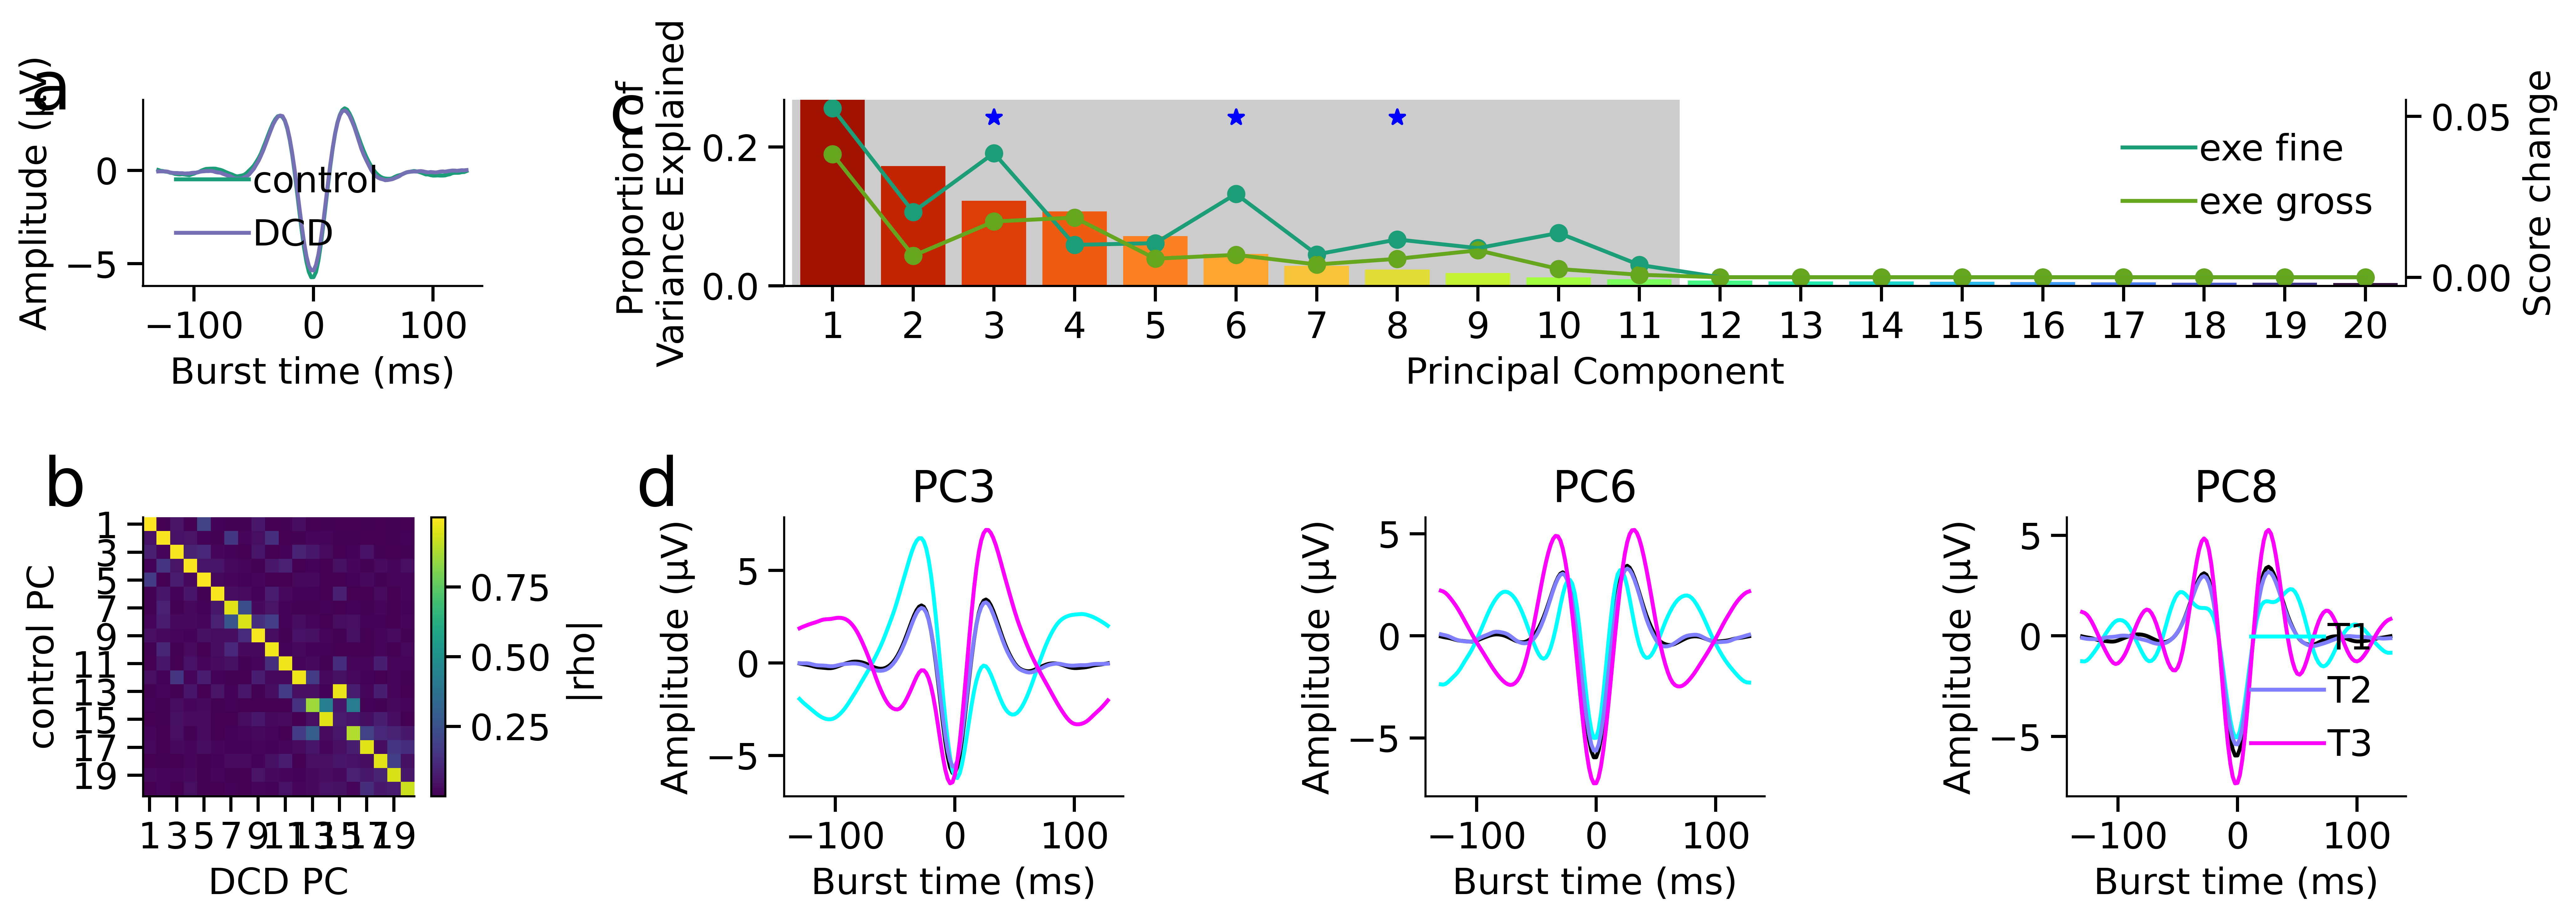

In [74]:
# Define colormap
col_r = plt.cm.cool(np.linspace(0, 1, num=4))

# Figure setup using GridSpec
fig = plt.figure(figsize=(14, 5), dpi=600, facecolor="white")
gs = GridSpec(2, 4, figure=fig, height_ratios=[1, 1.5])

ax = fig.add_subplot(gs[0, 0])
ax.plot(
    all_bursts['waveform_times']*1000, 
    np.median(all_bursts['waveform'][typ_idx,:],axis=0)*1e6,
    label='control', 
    color=typ_color
)
ax.plot(
    all_bursts['waveform_times']*1000, 
    np.median(all_bursts['waveform'][dcd_idx,:],axis=0)*1e6,
    label='DCD',
    color=dcd_color
)
ax.legend()
ax.set_xlabel('Burst time (ms)')
ax.set_ylabel('Amplitude (µV)')
add_subplot_label(ax, 'a')

ax = fig.add_subplot(gs[1, 0])
im=ax.imshow(pca_corr_matrix, cmap='viridis', aspect='auto')
plt.colorbar(im, label="|rho|")
ax.set_xlabel('DCD PC')
ax.set_ylabel('control PC')
ax.set_xticks(np.arange(0,20,2))
ax.set_xticklabels(np.arange(0,20,2)+1)
ax.set_yticks(np.arange(0,20,2))
ax.set_yticklabels(np.arange(0,20,2)+1)
add_subplot_label(ax, 'b')

# Top subplot: Variance explained plot
ax = fig.add_subplot(gs[0, 1:])  # Span all three columns
plt.rcParams.update({
    'font.size': 14,
    'axes.spines.right': True,
    'axes.spines.top': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})
PC_var_exp = pca.explained_variance_ratio_
PC_r = np.arange(PC_var_exp.shape[0]) + 1
shuf_plot=np.zeros(PC_var_exp.shape[0])
shuf_plot[shuffling_results]=np.max(PC_var_exp)
bar = ax.bar(PC_r, shuf_plot, lw=0.2, color="black", alpha=0.2, width=1)
bar = ax.bar(PC_r, PC_var_exp, lw=0.2)
cm = plt.cm.get_cmap("turbo_r")
for i in PC_r:
    plt.setp(bar[i-1],"facecolor", cm(i/20))
ax.set_xlabel("Principal Component")
ax.set_ylabel("Proportion of \nVariance Explained")
ax.set_ylim([0, PC_var_exp[0]])
_=ax.set_xticks(PC_r)
ax.set_xlim([.4,20.5])
ax2 = ax.twinx()

cmap = ListedColormap(plt.get_cmap("Dark2").colors[:6])
cond_colors = [cmap(0), cmap(4)]
for cond, color in zip(['exe fine', 'exe gross'], cond_colors):
    m_changes = np.mean(np.vstack([pc_score_changes['typ'][cond], pc_score_changes['dcd'][cond]]),axis=0)
    ax2.scatter(PC_r, m_changes, color=color)
    ax2.plot(PC_r, m_changes, label=cond, color=color)
for pc in modulated_pcs:
    ax.scatter(pc+1, PC_var_exp[0]-.025,marker='*',color='b')
ax2.set_ylabel("Score change")
plt.legend()
add_subplot_label(ax, 'c', x=-.085, y=1.1)
                  

plt.rcParams.update({
    'font.size': 14,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

n_q=3
    
col_r = plt.cm.cool(np.linspace(0, 1, num=n_q))
m_waveform = np.mean(all_bursts['waveform'][include_typ_idx,:],axis=0)*1e6


# Lower subplots: Waveforms
for p_idx, pc_idx in enumerate(modulated_pcs):
    ax_waveform = fig.add_subplot(gs[1, 1+p_idx])  # Grid for waveform subplots
    plt.plot(all_bursts['waveform_times']*1000, m_waveform, 'k')
    step=100/n_q
    q_bins = np.percentile(pca_components[pc_idx], np.arange(0,100+step,step))
    for q in range(n_q):
        q_idx = include_typ_idx & (pca_components[pc_idx]>=q_bins[q]) & (pca_components[pc_idx]<=q_bins[q+1])
        q_waveform = np.mean(all_bursts['waveform'][q_idx,:],axis=0)*1e6
        ax_waveform.plot(all_bursts['waveform_times']*1000, q_waveform, color=col_r[q,:], label=f'T{q+1}')
    ax_waveform.set_xlabel('Burst time (ms)')
    ax_waveform.set_ylabel('Amplitude (µV)')
    if p_idx==(len(modulated_pcs)-1):
        plt.legend(loc='lower right')
    ax_waveform.set_title(f'PC{pc_idx + 1}')
    if p_idx==0:
        add_subplot_label(ax_waveform, 'd', x=-.31)
        
plt.tight_layout()
plt.savefig('./manuscript/figX_burst_waveform_pca.pdf', dpi=600)

In [127]:
def plot_pc_burst_rate(condition_labels, pc_idx):
    WINDOWS = {
        "baseline": (-7.0, -1.0),
        "task": (1.0, 9.0),
        "post-task": (11.0, 14.0),
    }

    rows = []
    subjects = np.unique(all_bursts['subject'][np.where(include_typ_idx)[0]])
    typ_subj = np.unique(all_bursts['subject'][np.where(include_typ_idx & (all_bursts['group'] == 0))[0]])
    dcd_subj = np.unique(all_bursts['subject'][np.where(all_bursts['group'] == 1)[0]])

    condition_rates = {}
    for hemi in ['contra','ipsi']:
        condition_rates[hemi]={}
        for cond in condition_labels:
            condition_rates[hemi][cond] = {'typ': [], 'dcd': []}
            
    
    col_r = plt.cm.cool(np.linspace(0, 1, num=n_pc_bins))
    step = 100 / n_pc_bins
    t_bins = np.percentile(pca_components[pc_idx], np.arange(0, 100 + step, step))
    time_bin_size = .2
    time_bins = np.arange(-8, 15 + time_bin_size, time_bin_size)
    plt_time_bins = time_bins[:-1]
    t_idx=(time_bins[:-1]>=-7) & (time_bins[:-1]<=14)
    min_cluster_size=20
    
    for subject in subjects:
        if subject in typ_subj:
            group='typ'
        elif subject in dcd_subj:
            group='dcd'
        
        subj_idx = (all_bursts['subject'] == subject)
        for hemi in ['contra','ipsi']:
            for cond in condition_labels:
                event=condition_events[cond]
                cond_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['hemi'] == hemi) & (all_bursts['condition'] == event)])
                if len(cond_trials) >= min_trials_per_cond:
                    smoothed_bc_rates=[]
                    for t in range(n_pc_bins):
                        pc_bin_idx = (pca_components[pc_idx] >= t_bins[t]) & (pca_components[pc_idx] <= t_bins[t+1])
                        trial_rates=np.zeros((len(cond_trials), len(time_bins)-1))
                        for trial_idx, trial in enumerate(cond_trials):
                            unsmoothed_rate, _ = np.histogram(all_bursts['peak_time'][subj_idx & (all_bursts['hemi'] == hemi) & pc_bin_idx & (all_bursts['condition'] == event) & (all_bursts['trial']==trial)], bins=time_bins)
                            unsmoothed_rate = (unsmoothed_rate * (1 / time_bin_size))
                            smoothed_rate = gaussian_filter1d(unsmoothed_rate, sigma=smooth_kern, axis=0, mode="nearest")
                            
                            task_rate=float(np.mean(smoothed_rate[(time_bins[:-1] >= WINDOWS['task'][0]) & (time_bins[:-1] <= WINDOWS['task'][1])]))
                            base_rate=float(np.mean(smoothed_rate[(time_bins[:-1] >= WINDOWS['baseline'][0]) & (time_bins[:-1] <= WINDOWS['baseline'][1])]))
                            rows.append(
                                {
                                    "subject": subject,
                                    "group": group,
                                    "hemi": hemi,
                                    "condition": cond,
                                    'tertile': t,
                                    "rate": task_rate-base_rate,
                                }
                            )
                            trial_rates[trial_idx, :] = smoothed_rate
                        smoothed_rate = np.nanmean(trial_rates,axis=0)
                        smoothed_base_rate = np.mean(smoothed_rate[(time_bins[:-1]>=-7) & (time_bins[:-1]<=-1)])
                        smoothed_bc_rate = (smoothed_rate - smoothed_base_rate)
                        smoothed_bc_rates.append(smoothed_bc_rate)
                    condition_rates[hemi][cond][group].append(smoothed_bc_rates)
                    
    # Write to CSV
    out_df = pd.DataFrame(rows, columns=["subject", "group", "hemi", "condition", "tertile", "rate"])
    out_path = f"./trial_pc{pc_idx+1}_burst_rate_windows.csv"
    out_df.to_csv(out_path, index=False)

    plt_time_bins = time_bins[:-1]
    
    for hemi in ['contra','ipsi']:
        for cond in condition_labels:
            for group in condition_rates[hemi][cond]:
                condition_rates[hemi][cond][group]=np.array(condition_rates[hemi][cond][group])
                
            
    for cond in condition_labels:
        plt.figure(figsize=(10,9))
        ax_idx=0
        axes=[]
        for t in range(n_pc_bins):
            for hemi in ['contra','ipsi']:
                ax=plt.subplot(3,2,ax_idx+1)
                axes.append(ax)

                data = [condition_rates[hemi][cond]['typ'][:,t][:,t_idx], condition_rates[hemi][cond]['dcd'][:,t][:,t_idx]] 
                n1 = data[0].shape[0]
                n2 = data[1].shape[0]
                dof = n1 + n2 - 2
                t_crit = stats.t.ppf(1 - 0.05/2, dof)

                T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test(
                    data,
                    n_permutations=1000,
                    threshold=t_crit,
                    tail=0,
                    out_type='mask',
                    n_jobs=-1,
                    verbose=False
                )

                for g_idx, group in enumerate(['typ', 'dcd']):            
                    rates = condition_rates[hemi][cond][group][:,t,:]
                    m_rate=np.nanmean(rates[:,t_idx], axis=0)
                    se_rate=np.nanstd(rates[:,t_idx], axis=0)/np.sqrt(rates.shape[0])
                    style='-'
                    if group=='dcd':
                        style='--'
                    ax.plot(
                        plt_time_bins[t_idx],
                        m_rate,
                        color=col_r[t],
                        linestyle=style,
                        label=group
                    )
                    ax.fill_between(
                        plt_time_bins[t_idx],
                        m_rate-se_rate,
                        m_rate+se_rate,
                        color=col_r[t],
                        alpha=.25
                    )
                yl = ax.get_ylim()
                py = yl[1] + .1 * (yl[1] - 0)
                for cluster_slice, cluster_pval in zip(clusters, cluster_p_values):
                    if cluster_pval < 0.05:
                        sl = cluster_slice[0]
                        idx = np.arange(sl.start, sl.stop)
                        if len(idx)>min_cluster_size:
                            ax.plot(plt_time_bins[t_idx][idx], np.full_like(idx, py), '*', color='r')

                ax.legend()
                ax.axvline(0, color='k', linestyle='--')
                ax.axvline(10, color='k', linestyle='--')
                ax.axhline(0, color='k', linestyle='--')
                ax.set_title(f'PC{pc_idx+1} {cond}: {hemi}')
                ax.set_xlabel('Time (s)')
                if ax_idx==0 or ax_idx==2:
                    ax.set_ylabel(r'Burst rate ($\Delta$ Hz)')
                ax_idx=ax_idx+1
    
            
        ylims=np.array([ax.get_ylim() for ax in axes])
        yl=[np.min(ylims[:,0]), np.max(ylims[:,1])]
        for ax in axes:
            ax.set_ylim(yl)
        plt.tight_layout()
        plt.savefig(f'./manuscript/figX_pc_{pc_idx+1}_{cond}_rate.pdf',dpi=600)

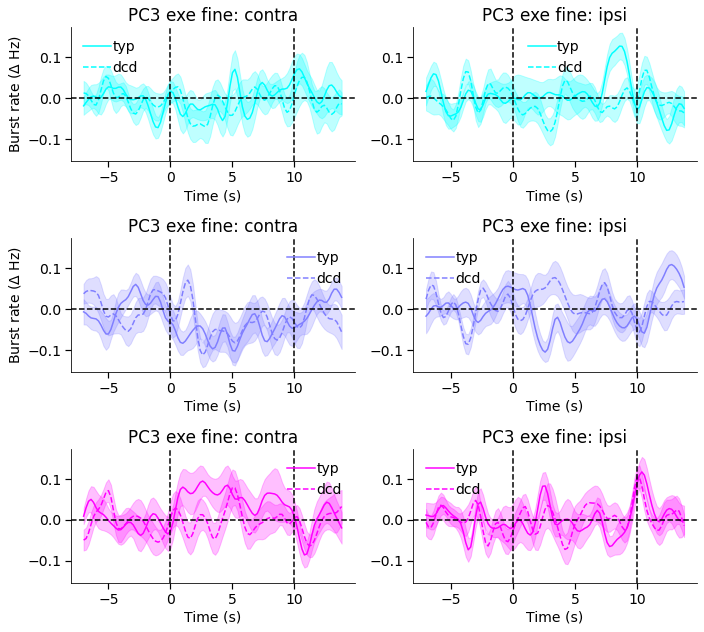

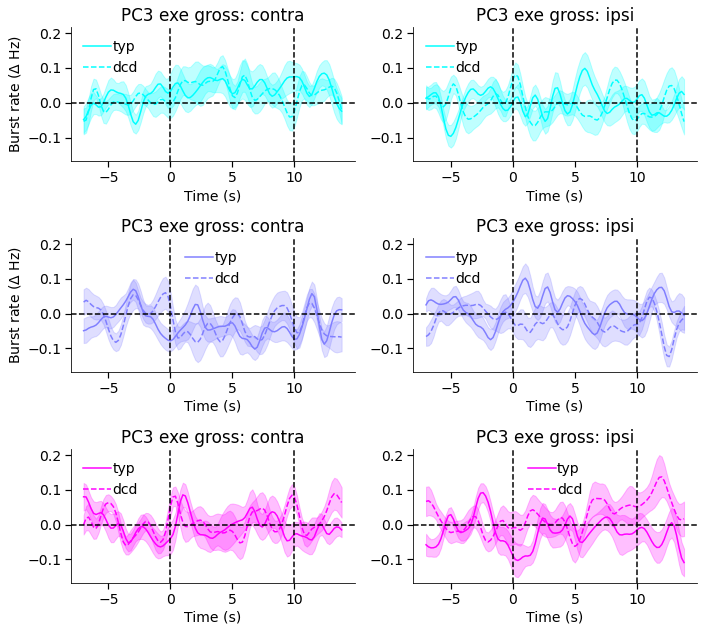

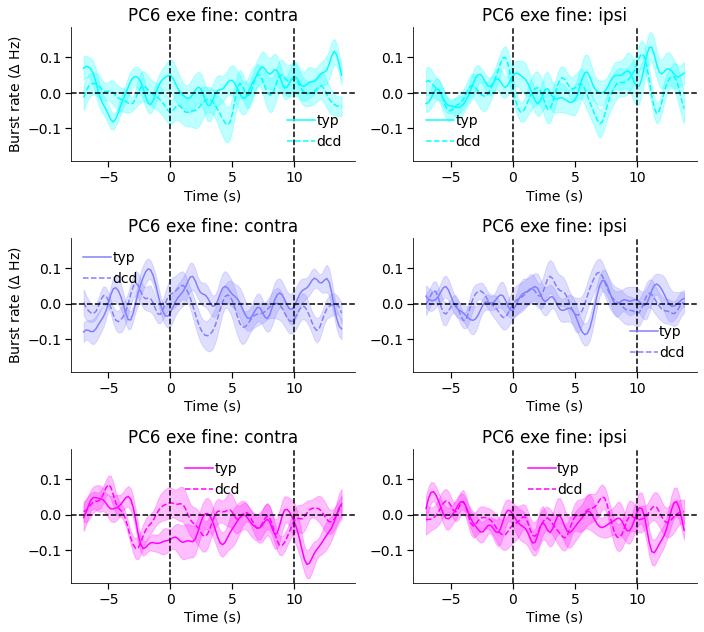

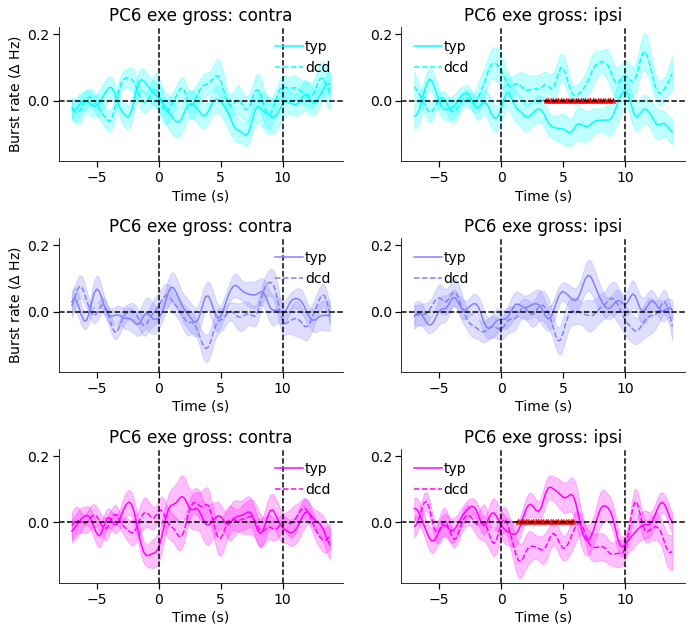

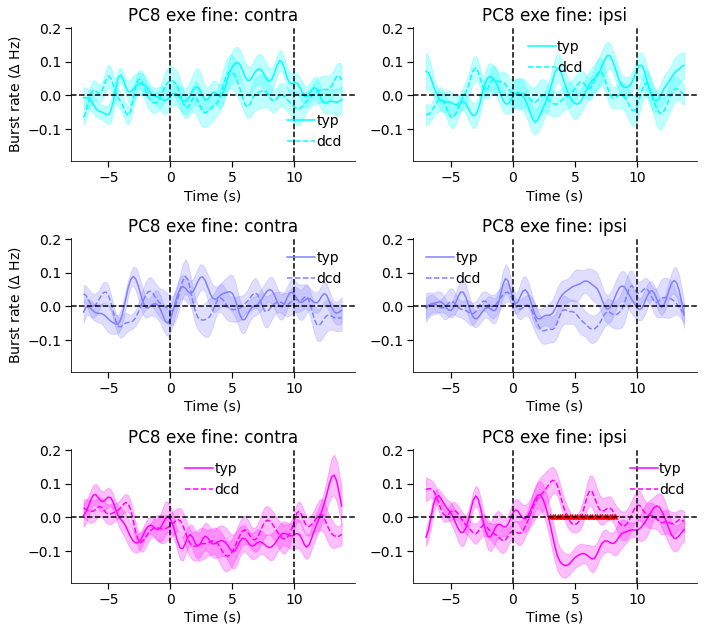

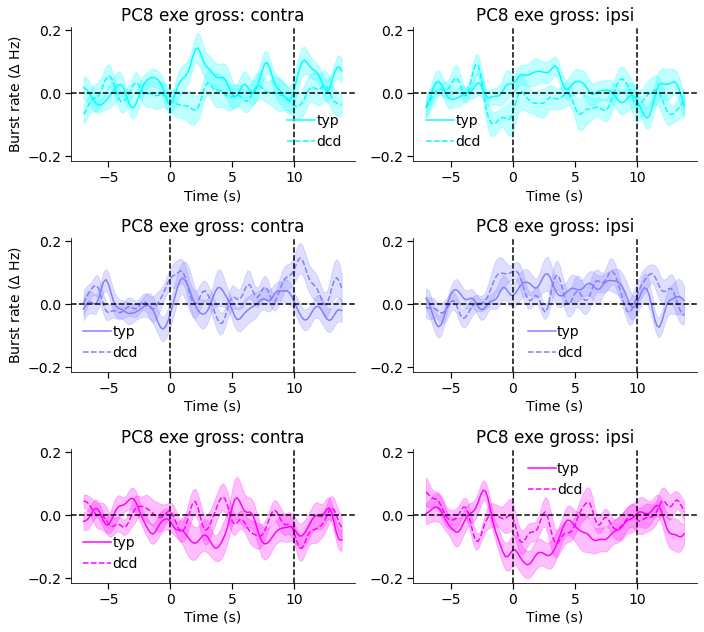

In [128]:
for pc in modulated_pcs:
    plot_pc_burst_rate(['exe fine','exe gross'], pc)

In [81]:
def bootstrap_regression_ci(x, y, x_fit, num_bootstrap=10000, ci=95):
    """
    Compute confidence intervals for regression predictions using bootstrapping.
    """
    n = len(x)
    bootstrap_predictions = np.zeros((num_bootstrap, len(x_fit)))
    
    for i in range(num_bootstrap):
        indices = np.random.choice(n, size=n, replace=True)
        x_sample = x[indices]
        y_sample = y[indices]
        slope, intercept, _, _, _ = linregress(x_sample, y_sample)
        bootstrap_predictions[i, :] = slope * x_fit + intercept

    lower_bound = (100 - ci) / 2
    upper_bound = 100 - lower_bound
    y_fit_lower = np.percentile(bootstrap_predictions, lower_bound, axis=0)
    y_fit_upper = np.percentile(bootstrap_predictions, upper_bound, axis=0)
    
    return y_fit_lower, y_fit_upper

import statsmodels.api as sm

def robust_fit_slope_intercept(x, y, kind="rlm_huber"):
    x = np.asarray(x)
    y = np.asarray(y)

    if kind == "rlm_huber":
        X = sm.add_constant(x)
        res = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit()
        intercept, slope = res.params
        return float(slope), float(intercept)

    raise ValueError("Unsupported kind")

In [86]:
def ols_hc3_pvalue(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    X = sm.add_constant(x)
    res = sm.OLS(y, X).fit(cov_type="HC3")
    intercept, slope = res.params
    p_value = res.pvalues[1]
    return float(slope), float(intercept), float(p_value)


def plot_pc_rate_behav(pc_idxs, conditions):

    hemi='ipsi'
    subjects = np.unique(all_bursts['subject'])
    typ_subj = np.unique(all_bursts['subject'][np.where(all_bursts['group'] == 0)[0]])
    dcd_subj = np.unique(all_bursts['subject'][np.where(all_bursts['group'] == 1)[0]])

    fig = plt.figure(figsize=(4*n_pc_bins+.5, 4*len(pc_idxs)))
    gs = fig.add_gridspec(len(pc_idxs), n_pc_bins)
    
    step=100/n_pc_bins
    for row_idx, (pc_idx, condition) in enumerate(zip(pc_idxs, conditions)):
        t_bins = np.percentile(pca_components[pc_idx], np.arange(0,100+step,step))

        avg_rates = {}
        behav_scores = {}
        for t in range(n_pc_bins):
            avg_rates[t] = {'typ': [], 'dcd': []}
            behav_scores[t] = {'typ': [], 'dcd': []}

        event=condition_events[condition]
        for subject in subjects:
            group = 'typ' if np.unique(all_bursts['group'][np.where(all_bursts['subject'] == subject)[0]])[0] == 0 else 'dcd'
            subj_idx = (all_bursts['subject'] == subject)             

            cond_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['condition'] == event)])

            if len(cond_trials)>=min_trials_per_cond:  

                mabc = df.loc[df['SubjectID'] == subject, 'MABC_TestScore']
                mabc_value = mabc.values[0] if not mabc.empty else np.nan


                for t in range(n_pc_bins):
                    pc_bin_idx = (pca_components[pc_idx] >= t_bins[t]) & (pca_components[pc_idx] <= t_bins[t+1])
                    trial_rates=np.zeros((len(cond_trials), len(time_bins)-1))
                    for trial_idx, trial in enumerate(cond_trials):
                        unsmoothed_rate, _ = np.histogram(all_bursts['peak_time'][subj_idx & pc_bin_idx & (all_bursts['hemi']==hemi) & (all_bursts['condition'] == event) & (all_bursts['trial']==trial)], bins=time_bins)
                        unsmoothed_rate = (unsmoothed_rate * (1 / time_bin_size))
                        smoothed_rate = gaussian_filter1d(unsmoothed_rate, sigma=smooth_kern, axis=0, mode="nearest")
                        trial_rates[trial_idx, :] = smoothed_rate
                    smoothed_rate = np.nanmean(trial_rates,axis=0)
                    smoothed_base_rate = np.mean(smoothed_rate[(time_bins[:-1]>=-7) & (time_bins[:-1]<=-1)])
                    smoothed_bc_rate = (smoothed_rate - smoothed_base_rate)# / smoothed_base_rate * 100
                    smoothed_bc_rate = np.mean(smoothed_bc_rate[(time_bins[:-1]>1) & (time_bins[:-1]<6)])

                    avg_rates[t][group].append(smoothed_bc_rate)
                    behav_scores[t][group].append(mabc_value) 
                    
        for t in range(n_pc_bins):
            ax = fig.add_subplot(gs[row_idx, t])
            ax.scatter(avg_rates[t]['typ'], behav_scores[t]['typ'],label='control',color=typ_color)
            ax.scatter(avg_rates[t]['dcd'], behav_scores[t]['dcd'],label='DCD',color=dcd_color)
            all_rates=np.hstack([avg_rates[t]['typ'], avg_rates[t]['dcd']])
            all_behav_scores=np.hstack([behav_scores[t]['typ'], behav_scores[t]['dcd']])
            good_idx=~np.isnan(all_behav_scores) & ~np.isnan(all_rates)

            rho, pval = spearmanr(all_rates[good_idx], all_behav_scores[good_idx])
            print(f'{hemi} {condition} PC{pc_idx+1} T{t+1}: all rho={rho:.2f}, p={pval:.3f}')

            for group in ['typ','dcd']:
                avg_rates[t][group]=np.array(avg_rates[t][group])
                behav_scores[t][group]=np.array(behav_scores[t][group])
                good_idx=~np.isnan(behav_scores[t][group]) & ~np.isnan(avg_rates[t][group])
                g_rho, g_pval = spearmanr(
                    avg_rates[t][group][good_idx], 
                    behav_scores[t][group][good_idx]
                )
                slope, intercept, p_value = ols_hc3_pvalue(
                    avg_rates[t][group][good_idx], 
                    behav_scores[t][group][good_idx]
                )

                print(f'{hemi} {condition} PC{pc_idx+1} T{t+1}: {group} rho={g_rho:.2f}, p={g_pval:.3f}, slope={slope:.2f}, p={p_value:.3f}')
        
                if p_value<0.05:
                    # Generate regression line
                    x_fit = np.linspace(np.min(all_rates), np.max(all_rates), 100)
                    y_fit = slope * x_fit + intercept
                    color=typ_color
                    if group=='dcd':
                        color=dcd_color
                    ax.plot(x_fit, y_fit, color=color)

                    # Bootstrapping for confidence intervals
                    y_fit_lower, y_fit_upper = bootstrap_regression_ci(
                        avg_rates[t][group][good_idx], 
                        behav_scores[t][group][good_idx], 
                        x_fit
                    )

                    # Confidence interval shading
                    ax.fill_between(x_fit, y_fit_lower, y_fit_upper, color=color, alpha=0.3)
            ax.set_title(f'PC{pc_idx+1} T{t+1} {condition}')
            if row_idx==len(pc_idxs)-1:
                    ax.set_xlabel('Burst rate')
            if t==0:
                ax.set_ylabel('Behav')
            if t==n_pc_bins-1 and row_idx==0:
                plt.legend()            

    plt.tight_layout()
    plt.savefig(f'./manuscript/figX_pc_burst_rate_pc_behav.pdf')

ipsi exe gross PC6 T1: all rho=-0.55, p=0.000
ipsi exe gross PC6 T1: typ rho=-0.39, p=0.050, slope=-28.85, p=0.020
ipsi exe gross PC6 T1: dcd rho=-0.37, p=0.115, slope=-47.03, p=0.039
ipsi exe gross PC6 T2: all rho=0.14, p=0.370
ipsi exe gross PC6 T2: typ rho=0.04, p=0.843, slope=2.16, p=0.900
ipsi exe gross PC6 T2: dcd rho=0.07, p=0.786, slope=7.78, p=0.745
ipsi exe gross PC6 T3: all rho=0.54, p=0.000
ipsi exe gross PC6 T3: typ rho=0.60, p=0.001, slope=30.63, p=0.000
ipsi exe gross PC6 T3: dcd rho=0.41, p=0.081, slope=38.07, p=0.023
ipsi exe fine PC8 T1: all rho=0.01, p=0.962
ipsi exe fine PC8 T1: typ rho=-0.07, p=0.749, slope=-5.82, p=0.701
ipsi exe fine PC8 T1: dcd rho=-0.06, p=0.810, slope=9.19, p=0.824
ipsi exe fine PC8 T2: all rho=0.09, p=0.540
ipsi exe fine PC8 T2: typ rho=-0.03, p=0.902, slope=3.01, p=0.851
ipsi exe fine PC8 T2: dcd rho=-0.16, p=0.531, slope=-18.89, p=0.175
ipsi exe fine PC8 T3: all rho=-0.42, p=0.004
ipsi exe fine PC8 T3: typ rho=-0.31, p=0.130, slope=-23.52, 

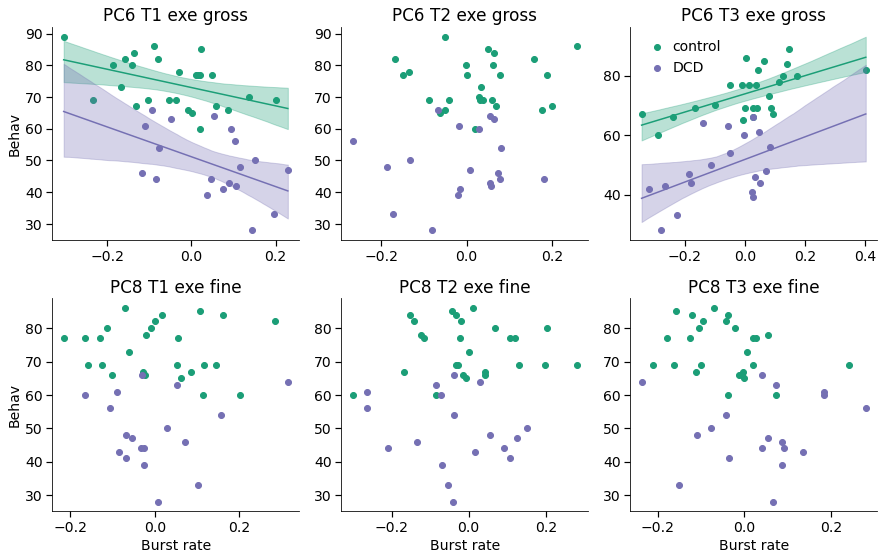

In [87]:
plot_pc_rate_behav([5,7], ['exe gross','exe fine'])